In [4]:
import torch, os; print(torch.__version__, torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
torch.set_float32_matmul_precision("medium")   # or "high"

2.5.1 12.1
GPU: NVIDIA RTX 4000 Ada Generation Laptop GPU


In [3]:
from pathlib import Path
import sys
nb_dir        = Path.cwd()                     # …/SHPB_Johnson_Cook/notebooks
proj_root     = nb_dir.parent                 # …/SHPB_Johnson_Cook
jc_scripts    = proj_root / "scripts"
sys.path.insert(0, str(jc_scripts))

from pinn_data     import SHPBDataNPZ, build_dataloaders
from pinn_model    import JCPINN          # updated as noted
#from jc_layer   import JCParameterLayer
import matplotlib.pyplot as plt
import numpy as np
import torch, torch.nn as nn, pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger

## Data Loading

In [5]:
data_dir = Path(r"..\pinn_dataset\A356\npz")

train_loader, val_loader = build_dataloaders(
    root_dir=data_dir,
    batch_size=1,
    val_ratio=0.2,
    num_workers=4,                       
    seed=1301,
    debug=False,
    persistent_workers=True,   # add to pinn_data.py’s DataLoader kwargs
)

## Data Visualization


Sample: ECG_20250426_A356_LAB_RT_007
  L0 (mm)  : 6.36
  A0 (mm²) : 30.58
  D0 (mm)  : 6.24
  Tags     : {'uid': ['ECG_20250426_A356_LAB_RT_007'], 'material': ['A356'], 'processing': ['3DPrinted'], 'test_mode': ['LAB'], 'test_date': ['20250426'], 'test_temperature': ['RT'], 'test_id': ['007']}


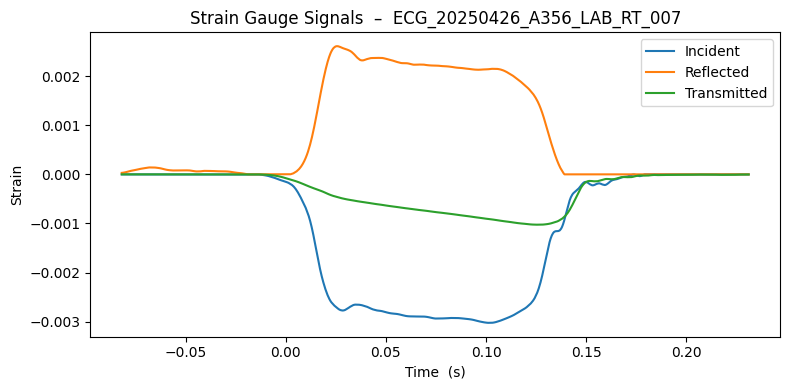


Sample: ECG_20250426_A356_LAB_RT_010
  L0 (mm)  : 6.39
  A0 (mm²) : 30.29
  D0 (mm)  : 6.21
  Tags     : {'uid': ['ECG_20250426_A356_LAB_RT_010'], 'material': ['A356'], 'processing': ['3DPrinted'], 'test_mode': ['LAB'], 'test_date': ['20250426'], 'test_temperature': ['RT'], 'test_id': ['010']}


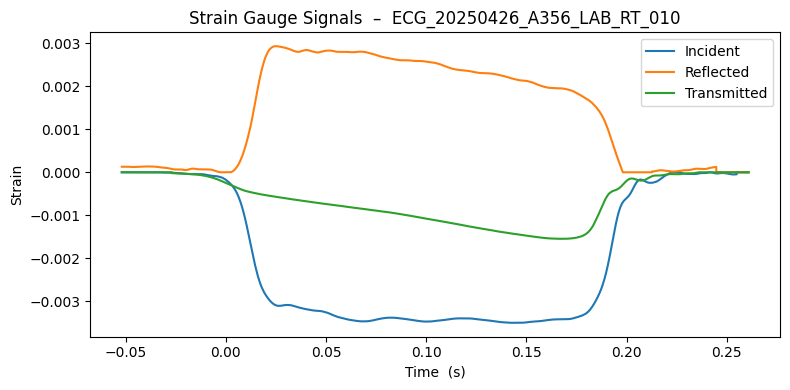


Sample: DKS_20250507_A356_LAB_RT_014
  L0 (mm)  : 6.31
  A0 (mm²) : 31.37
  D0 (mm)  : 6.32
  Tags     : {'uid': ['DKS_20250507_A356_LAB_RT_014'], 'material': ['A356'], 'processing': ['3DPrinted'], 'test_mode': ['LAB'], 'test_date': ['20250507'], 'test_temperature': ['RT'], 'test_id': ['014']}


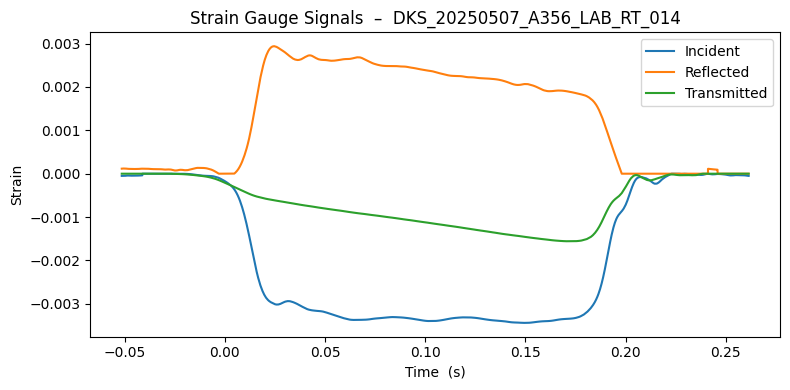

In [6]:
# -----------------------------------------------------------------------------
# Loop over the first three training experiments
# -----------------------------------------------------------------------------

for i, batch in enumerate(train_loader):
    if i == 3:
        break
        
    # ---- unpack tensors 
    uid  = batch["tags"]["uid"][0]
    time = batch["time"][0].numpy()
    inc  = batch["incident_raw"][0].numpy()
    refl = batch["reflected_raw"][0].numpy()
    tran = batch["transmitted_raw"][0].numpy()

    L0   = float(batch["L0_mm"][0])
    A0   = float(batch["A0_mm2"][0])
    D0   = float(batch["D0_mm"][0])

    # ---- print human-readable meta 
    print(f"\nSample: {uid}")
    print(f"  L0 (mm)  : {L0:.2f}")
    print(f"  A0 (mm²) : {A0:.2f}")
    print(f"  D0 (mm)  : {D0:.2f}")
    print(f"  Tags     : {batch['tags']}")

    # ---- plot the three raw strains 
    plt.figure(figsize=(8, 4))
    plt.plot(time, inc,  label="Incident")
    plt.plot(time, refl, label="Reflected")
    plt.plot(time, tran, label="Transmitted")
    plt.title(f"Strain Gauge Signals  –  {uid}")
    plt.xlabel("Time  (s)")
    plt.ylabel("Strain")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [28]:
# --- 2.1  Elastic / bar constants -------------------------------
E_s = 193.974  # specimen elastic modulus [GPa]  SS316
E_s = 68.948   # A356


bar_const = dict(
    E_bar  = 199.99,   # GPa
    c_bar  = 4953.321, # mm/ms
    rho_bar= 7.8e-3,   # kg/mm³
    Cp     = 0.46,     # kN·mm/tonne·K
    chi    = 0.9,      # adiabatic fraction
    bar_cross = 71.26  # mm²
)

# --- 2.2  Johnson–Cook bounds  ---------------------------------
bounds = dict(
    A=(0.130, 0.350),    # GPA
    B=(0.1, 1.500),
    n=(0.05, 0.60),
    C=(0.005, 0.06),
    m=(0.5,  1.5),
)

# --- 2.3  Initial JC-Parameters (literature guess or previous FEA card) --
theta_init_ss316 = dict(
    A=0.28846,            
    B=1.042,
    n=0.254013,
    C=0.022,
    m=1.0,
)

# For A356

theta_init = dict(
    A=0.165,            
    B=0.1903,
    n=0.240194,
    C=0.0313,
    m=1.0,
)


In [8]:
import importlib          # built-in
import pinn_model         # first import

# … work with pinn_model.JCPINN …

# ── later, after you edited pinn_model.py ──
importlib.reload(pinn_model)          # re-execute the file
JCPINN = pinn_model.JCPINN            # get the (fresh) class object


model = JCPINN(
    bar_const       = bar_const,
    spec_E          = E_s,
    bounds          = bounds,
    theta_init      = theta_init,
    rho_s = 2.67e-3,                  #rho_s = 7.6e-3 for steel,   2.67e-3 for Al  # Specimen density
    Cp_s =  0.963,                   #Cp_s = 0.46 for steel,  0.963 for AL                       # Specimen Specific Heat capacity
    T_room = 293.0,                  # Room Temperature (kelvin)
    T_melt = 1023.15,                # T_melt = 1673.0 for steel, 1023.15 for AL                 # Specimen melting temperature (kelvin)
    beta = 0.9,                      # Specimen Adiabatic Factor
    lambda_sig      = 20.0,
    lambda_reg      = 1e-3,
    lr_adam         = 5e-5,
)

batch = next(iter(train_loader))          # one experiment
model.eval()
with torch.no_grad():
    loss = model.compute_loss(batch)
print("Initial L_sig:", loss.item())
print("θ_init:", model.jc.as_dict())


Initial L_sig: 0.21724280714988708
θ_init: {'A': 0.16499999165534973, 'B': 0.19030000269412994, 'n': 0.24019400775432587, 'C': 0.031300000846385956, 'm': 1.0}


In [9]:
import pytorch_lightning as pl

class JCLogger(pl.callbacks.Callback):
    """
    • Prints θ and val_L_sig every <every> epochs.
    • Logs the same scalars to the active TensorBoard logger.
    """
    def __init__(self, every: int = 25):
        self.every = every

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.current_epoch % self.every:
            return

        # ---- fetch values -------------------------------------------------
        theta = pl_module.jc.as_dict()          # {'A':…, 'B':…}
        val_L_sig = trainer.callback_metrics.get("val_L_sig")
        lr        = trainer.callback_metrics.get("lr-Adam")   # may be None
        
        # console print (unchanged)
        val_txt = f"{val_L_sig:.3e}" if val_L_sig is not None else "n/a"
        lr_txt  = f"{lr:.2e}"        if lr        is not None else "n/a"
        print(f"E{trainer.current_epoch:04d} | "
              f"A={theta['A']:.3f} B={theta['B']:.3f} "
              f"n={theta['n']:.3f} C={theta['C']:.4f} m={theta['m']:.3f} | "
              f"val_L_sig={val_txt} lr={lr_txt}")
        
        # TensorBoard scalars
        writer = trainer.logger.experiment
        step   = trainer.global_step
        writer.add_scalar("loss/val_L_sig", val_L_sig, step)
        for k, v in theta.items():
            writer.add_scalar(f"theta/{k}", v, step)
        # log LR only when available
        if lr is not None:
            writer.add_scalar("lr/Adam", lr, step)


In [77]:
from pytorch_lightning.callbacks import LearningRateMonitor
lr_mon = LearningRateMonitor(logging_interval="epoch")
jc_log = JCLogger(every=25)

trainer = pl.Trainer(
    max_epochs        = 800,
    accelerator       = "gpu",
    precision         = 32,
    log_every_n_steps = 1,
    gradient_clip_val = 1.0,
    gradient_clip_algorithm = "norm",
    logger            = TensorBoardLogger("tb_logs", name="pinnA356"),
    callbacks = [
        pl.callbacks.ModelCheckpoint(monitor="val_L_sig", mode="min"),
        pl.callbacks.EarlyStopping(monitor="val_L_sig", patience=50, mode="min"),
        lr_mon,
        jc_log,
    ],
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [78]:
trainer.fit(model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type             | Params | Mode
-------------------------------------------------
0 | jc   | JCParameterLayer | 5      | eval
-------------------------------------------------
5         Trainable params
0         Non-trainable params
5         Total params
0.000     Total estimated model params size (MB)
0         Modules in train mode
1         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

E0000 | A=0.165 B=0.190 n=0.240 C=0.0313 m=1.000 | val_L_sig=1.514e-01 lr=n/a


Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

In [10]:
model.jc.as_dict()

{'A': 0.16499999165534973,
 'B': 0.19030000269412994,
 'n': 0.24019400775432587,
 'C': 0.031300000846385956,
 'm': 1.0}

In [11]:
theta_init

{'A': 0.165, 'B': 0.1903, 'n': 0.240194, 'C': 0.0313, 'm': 1.0}

C:\Users\ecazares3\AppData\Local\Temp\ipykernel_195636\2739032834.py:30: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  eps_exp_true = np.log(1 + eps_exp[0].cpu())


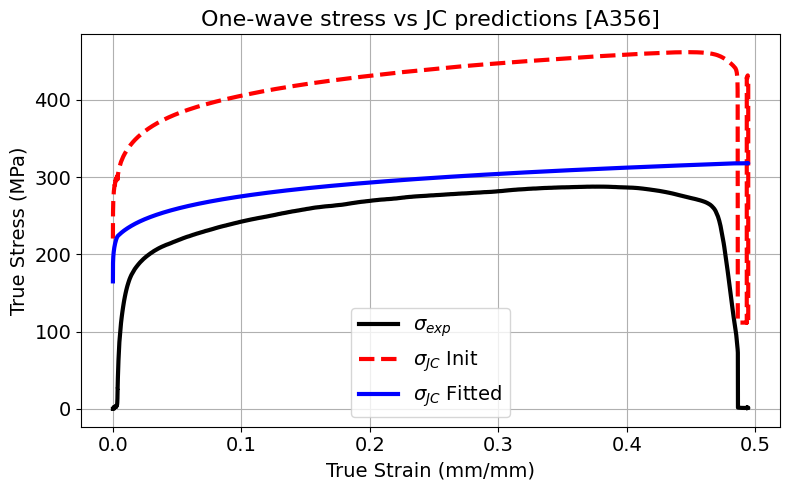

In [13]:
# ---------------------------------------------------------------------
# helper: JC stress for arbitrary θ
# ---------------------------------------------------------------------
def jc_stress(theta_dict, eps_pl, eps_pl_dot, T_star, eps0=1e-6):
    A, B, n, C, m = (theta_dict[k] for k in ("A", "B", "n", "C", "m"))
    log_term = torch.log(torch.clamp(eps_pl_dot / eps0, min=1e-9))
    return (A + B * eps_pl**n) * (1 + C * log_term) * (1 - T_star)**m

# ---------------------------------------------------------------------
# make sure the model has a physics_from_batch hook
# ---------------------------------------------------------------------
import types, torch

# ---------------------------------------------------------------------
# pick one experiment
# ---------------------------------------------------------------------
batch = next(iter(val_loader))
batch = {k: v.to(model.device) if torch.is_tensor(v) else v for k, v in batch.items()}
with torch.no_grad():    
    time, sig_1w_exp,  sig_jc_tr, eps_exp, eps_pl, eps_pl_dot, T_star = model._forward_physics(batch, return_all=True)

# JC with the initial θ (stored when the layer was built)
sig_jc_init = jc_stress(theta_init, eps_pl[0], eps_pl_dot[0], T_star[0])

# ---------------------------------------------------------------------
# plot
# ---------------------------------------------------------------------
# take only sample 0 for every curve
t            = time[0].cpu()                  # (T,)
eps_exp_true = np.log(1 + eps_exp[0].cpu())
sig_exp_true = sig_1w_exp[0].cpu() * (1 + eps_exp[0].cpu())          # (T,)
sig_pred_tr  = sig_jc_tr[0].cpu()             # (T,) ← slice here
sig_pred_ini = sig_jc_init.cpu()              # already (T,)

plt.figure(figsize=(8, 5))
plt.plot(-eps_exp_true, -sig_exp_true*1e3,   "k",  label="$\sigma_{exp}$", lw = 3)
plt.plot(-eps_exp_true, sig_pred_ini*1e3,    "r--",label="$\sigma_{JC}$ Init", lw =3)
plt.plot(-eps_exp_true, sig_pred_tr*1e3,     "b",  label="$\sigma_{JC}$ Fitted", lw=3)
plt.xlabel("True Strain (mm/mm)", fontsize=14); plt.ylabel("True Stress (MPa)", fontsize=14)
plt.title("One-wave stress vs JC predictions [A356]", fontsize=16)
plt.xticks(fontsize=14); plt.yticks(fontsize=14)
plt.grid()
plt.legend(fontsize = 14); plt.tight_layout()
plt.savefig("A356_pinn_predict.png", dpi = 300)
plt.show()




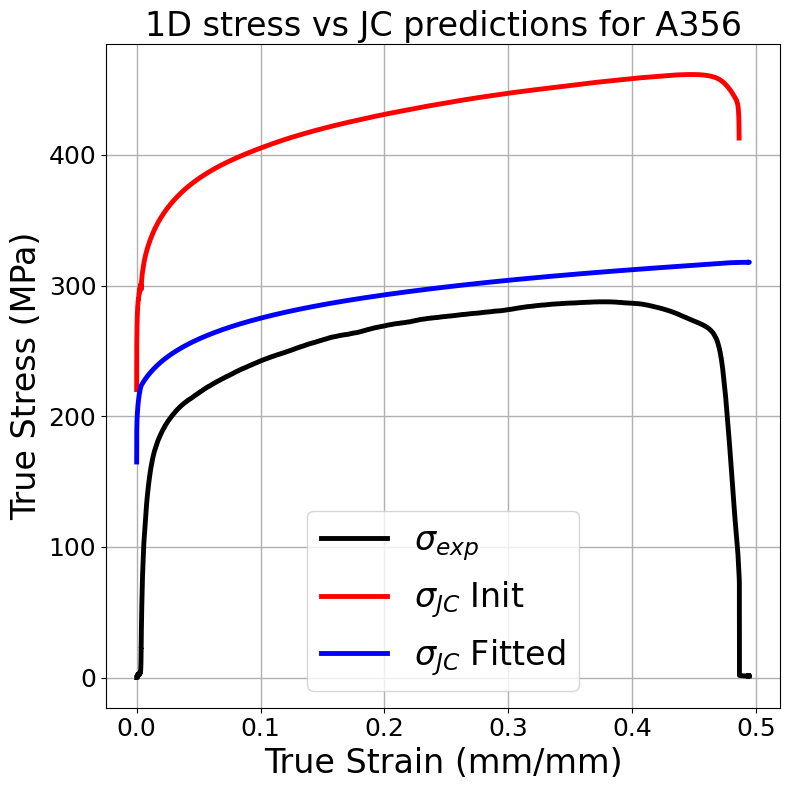

In [36]:
plt.figure(figsize=(8, 8))
plt.plot(-eps_exp_true, -sig_exp_true*1e3,   "k",  label="$\sigma_{exp}$", lw = 3.5)
plt.plot(-eps_exp_true[:-7000], sig_pred_ini[:-7000]*1e3,    "r-",label="$\sigma_{JC}$ Init", lw =3.5)
plt.plot(-eps_exp_true, sig_pred_tr*1e3,     "b",  label="$\sigma_{JC}$ Fitted", lw=3.5)
plt.xlabel("True Strain (mm/mm)", fontsize=24); plt.ylabel("True Stress (MPa)", fontsize=24)
plt.title("1D stress vs JC predictions for A356", fontsize=24)
plt.xticks(fontsize=18); plt.yticks(fontsize=18)
plt.grid(lw=1)
plt.legend(fontsize = 24); plt.tight_layout()
plt.savefig(r"D:\LaTex\W-Ta Proposal\figures\pinn_pred.png", dpi=300)
plt.show()